## Chat myPDF : RAG with LLAMA, LangChain, Ollama, and FAISS Vector Store
### 2. Retrievals and Augmented Data Generation (RAG) with Context-Aware Chunking

RAG PDF Dataset: https://github.com/laxmimerit/rag-dataset

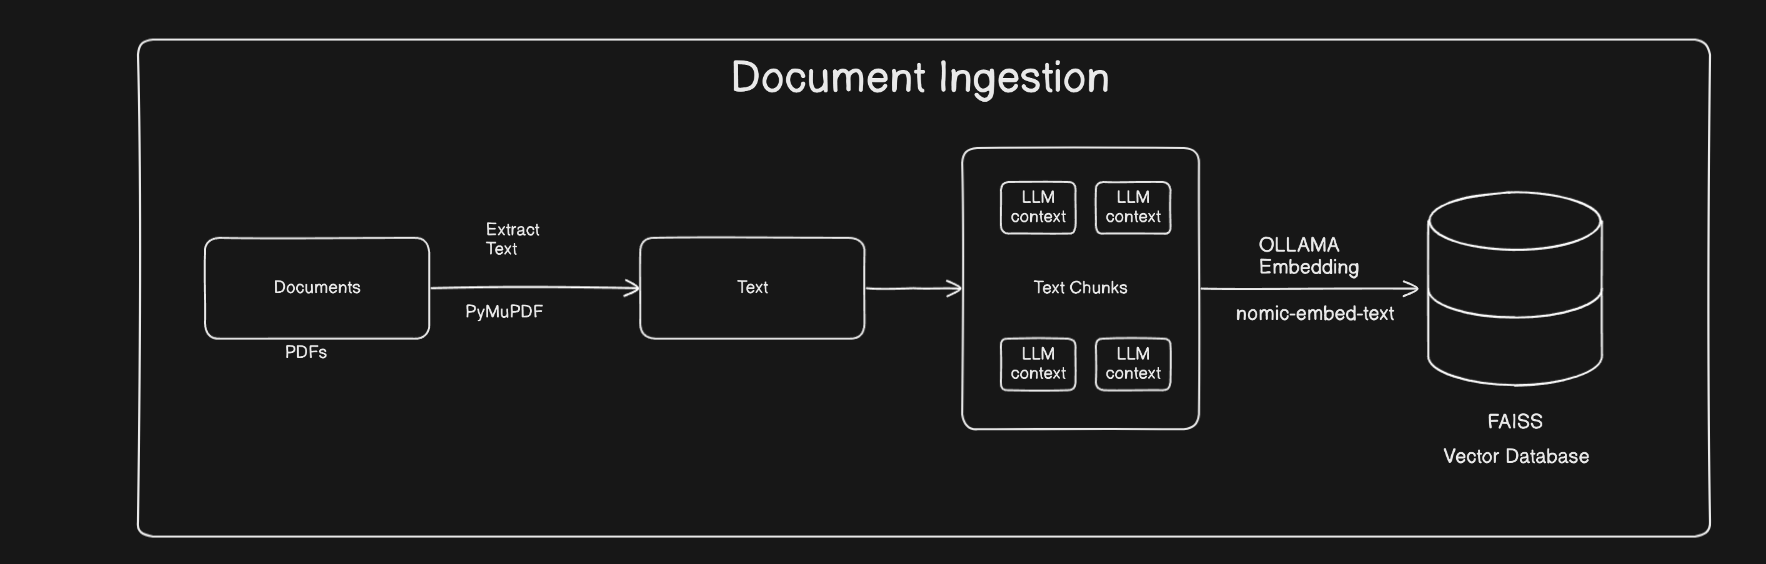

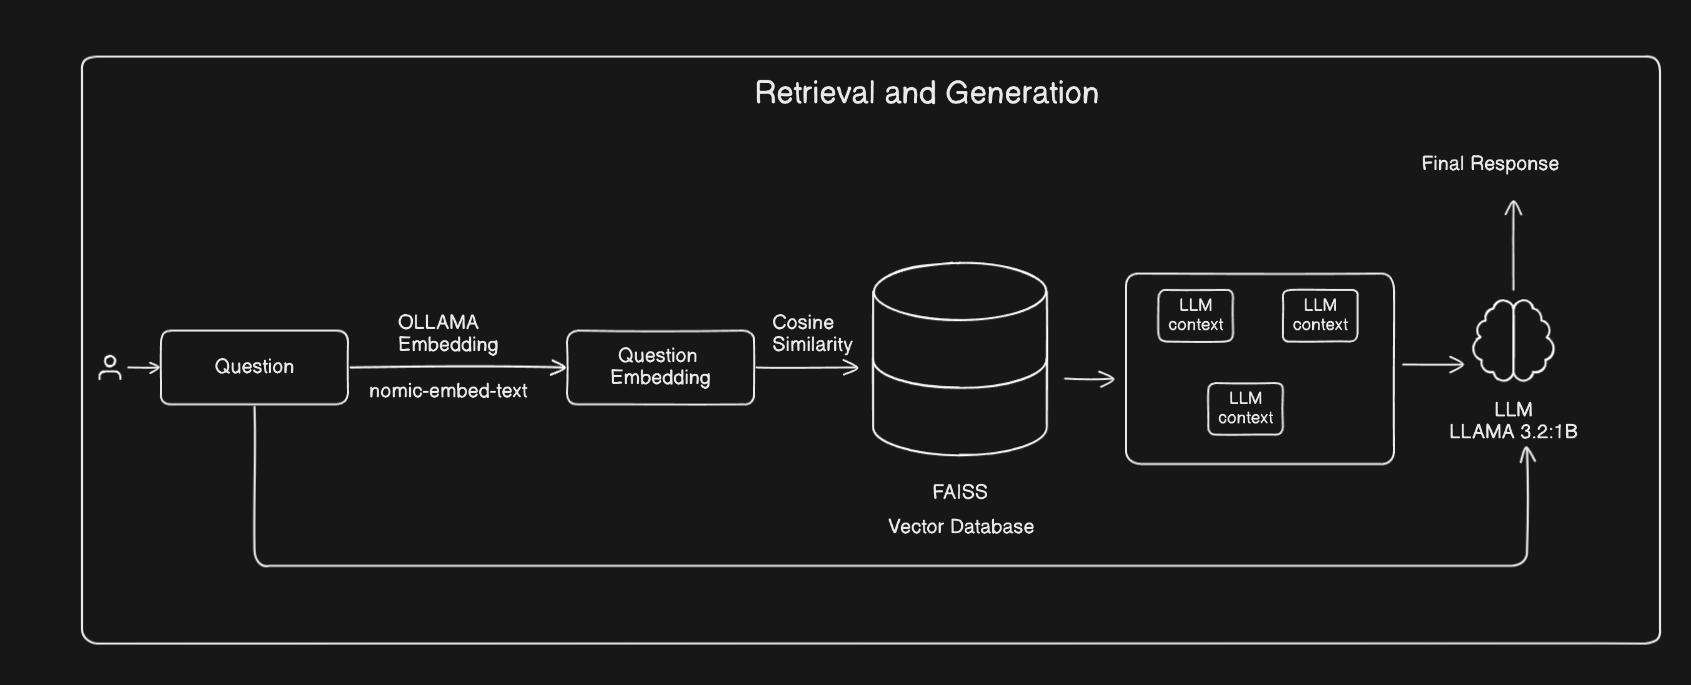

In [122]:
import os
import warnings
from dotenv import load_dotenv

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

load_dotenv()

True

### Document Loader

In [123]:
### Read the list of PDFs in the dir

from langchain_community.document_loaders import PyMuPDFLoader
import os

pdfs = []
for root, dirs, files in os.walk("rag-dataset"):
    # print(root, dirs, files)
    for file in files:
        if file.endswith(".pdf"):
            pdfs.append(os.path.join(root, file))


In [124]:
docs = []
for pdf in pdfs:
    loader = PyMuPDFLoader(pdf)
    temp = loader.load()
    docs.extend(temp)

    # print(temp)
    # break

In [125]:
len(docs)

131

In [126]:
print(docs[0].page_content)
docs

Constitution of Kenya 
 Kenya
CONSTITUTION OF KENYA
Published in Kenya Gazette Vol. CXII—No. 88 on 3 September 2010
Assented to on 4 August 2010
Commenced on 27 August 2010 by  Promulgation
PREAMBLE
We, the people of Kenya—
ACKNOWLEDGING the supremacy of the Almighty God of all creation:
HONOURING those who heroically struggled to bring freedom and justice to our land:
PROUD of our ethnic, cultural and religious diversity, and determined to live in peace and unity as one
indivisible sovereign nation:
RESPECTFUL of the environment, which is our heritage, and determined to sustain it for the beneﬁt of future
generations:
COMMITTED to nurturing and protecting the well-being of the individual, the family, communities and the
nation:
RECOGNISING the aspirations of all Kenyans for a government based on the essential values of human rights,
equality, freedom, democracy, social justice and the rule of law:
EXERCISING our sovereign and inalienable right to determine the form of governance of ou

[Document(metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 0}, page_content='Constitution of Kenya \n Kenya\nCONSTITUTION OF KENYA\nPublished in Kenya Gazette Vol. CXII—No. 88 on 3 September 2010\nAssented to on 4 August 2010\nCommenced on 27 August 2010 by  Promulgation\nPREAMBLE\nWe, the people of Kenya—\nACKNOWLEDGING the supremacy of the Almighty God of all creation:\nHONOURING those who heroically struggled to bring freedom and justice to our land:\nPROUD of our ethnic, cultural and religious diversity, and determined to live in peace

### Document Chunking

In [127]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from langchain_ollama import OllamaEmbeddings
from tqdm import tqdm

# Initialize embeddings model
print("🔧 Initializing embeddings model...")
embeddings = OllamaEmbeddings(model='nomic-embed-text', base_url='http://localhost:11434')

# Test the embeddings connection
try:
    test_embedding = embeddings.embed_query("test")
    print(f"✅ Embeddings model initialized successfully! (Dimension: {len(test_embedding)})")
except Exception as e:
    print(f"❌ Error connecting to Ollama: {e}")
    print("Please ensure Ollama is running and the 'nomic-embed-text' model is pulled.")
    print("Run: ollama pull nomic-embed-text")
    raise

def semantic_chunk(docs, embeddings, similarity_threshold=0.8):
    """
    Context-aware chunking based on semantic similarity, not fixed size.
    Chunks are created at semantic boundaries using embedding similarity.
    
    Args:
        docs: List of LangChain Document objects
        embeddings: Embedding model (OllamaEmbeddings)
        similarity_threshold: Threshold for determining topic boundaries (0-1)
    
    Returns:
        List of LangChain Document objects with semantically coherent chunks
    """
    from langchain.schema import Document
    
    all_chunks = []
    
    print(f"\n📚 Processing {len(docs)} documents with semantic chunking...")
    print(f"🎯 Similarity threshold: {similarity_threshold}")
    
    for doc_idx, doc in enumerate(tqdm(docs, desc="Processing documents")):
        text = doc.page_content
        metadata = doc.metadata
        
        # Skip empty documents
        if not text or not text.strip():
            continue
        
        # Split into sentences
        sentences = text.split('. ')
        sentences = [s.strip() for s in sentences if s.strip()]
        
        if len(sentences) == 0:
            continue
        
        # For very short documents with only one sentence, create a single chunk
        if len(sentences) == 1:
            chunk_doc = Document(
                page_content=sentences[0] + '.',
                metadata=metadata.copy()
            )
            all_chunks.append(chunk_doc)
            continue
        
        # Get embeddings for all sentences in batches for efficiency
        try:
            sentence_embeddings = []
            batch_size = 10  # Process sentences in batches to avoid overwhelming the API
            
            for i in range(0, len(sentences), batch_size):
                batch = sentences[i:i + batch_size]
                for sentence in batch:
                    if sentence:  # Skip empty sentences
                        embedding = embeddings.embed_query(sentence)
                        sentence_embeddings.append(embedding)
        except Exception as e:
            print(f"\n⚠️  Error processing document {doc_idx + 1}: {e}")
            # If embedding fails, treat the entire document as one chunk
            chunk_doc = Document(
                page_content=text,
                metadata=metadata.copy()
            )
            all_chunks.append(chunk_doc)
            continue
        
        # Build chunks based on semantic similarity
        chunks = []
        current_chunk = [sentences[0]]
        
        for i in range(len(sentence_embeddings) - 1):
            # Calculate cosine similarity between consecutive sentences
            emb1 = np.array(sentence_embeddings[i]).reshape(1, -1)
            emb2 = np.array(sentence_embeddings[i+1]).reshape(1, -1)
            similarity = cosine_similarity(emb1, emb2)[0][0]
            
            if similarity > similarity_threshold:  # Same topic
                current_chunk.append(sentences[i+1])
            else:  # Topic boundary detected
                chunks.append('. '.join(current_chunk) + '.')
                current_chunk = [sentences[i+1]]
        
        # Add the last chunk
        if current_chunk:
            chunks.append('. '.join(current_chunk) + '.')
        
        # Convert chunks back to LangChain Document objects
        for chunk_text in chunks:
            chunk_doc = Document(
                page_content=chunk_text,
                metadata=metadata.copy()
            )
            all_chunks.append(chunk_doc)
    
    print(f"\n✅ Semantic chunking complete!")
    print(f"📊 Created {len(all_chunks)} chunks from {len(docs)} documents")
    return all_chunks

# Apply context-aware semantic chunking
chunks = semantic_chunk(docs, embeddings, similarity_threshold=0.8)

🔧 Initializing embeddings model...
✅ Embeddings model initialized successfully! (Dimension: 768)

📚 Processing 131 documents with semantic chunking...
🎯 Similarity threshold: 0.8
✅ Embeddings model initialized successfully! (Dimension: 768)

📚 Processing 131 documents with semantic chunking...
🎯 Similarity threshold: 0.8


Processing documents: 100%|██████████| 131/131 [00:00<00:00, 197.85it/s]


✅ Semantic chunking complete!
📊 Created 142 chunks from 131 documents


In [139]:
# chunks
len(chunks)

142

In [129]:
# Diagnostic: Analyze the semantic chunking results
print("📊 SEMANTIC CHUNKING ANALYSIS")
print("="*60)
print(f"Total chunks created: {len(chunks)}")
print(f"Original documents: {len(docs)}")
print(f"Average chunks per document: {len(chunks)/len(docs):.2f}")
print()

# Analyze chunk sizes
chunk_lengths = [len(chunk.page_content) for chunk in chunks]
print(f"Chunk size statistics:")
print(f"  Min: {min(chunk_lengths)} chars")
print(f"  Max: {max(chunk_lengths)} chars")
print(f"  Average: {sum(chunk_lengths)/len(chunk_lengths):.0f} chars")
print()

# Show first few chunks as examples
print("📄 Sample chunks:")
print("-"*60)
for i, chunk in enumerate(chunks[:3]):
    print(f"\nChunk {i+1}:")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Content preview: {chunk.page_content[:200]}...")
    print(f"Metadata: {chunk.metadata}")
print("\n" + "="*60)

📊 SEMANTIC CHUNKING ANALYSIS
Total chunks created: 142
Original documents: 131
Average chunks per document: 1.08

Chunk size statistics:
  Min: 8 chars
  Max: 3449 chars
  Average: 2106 chars

📄 Sample chunks:
------------------------------------------------------------

Chunk 1:
Length: 83 chars
Content preview: Constitution of Kenya 
 Kenya
CONSTITUTION OF KENYA
Published in Kenya Gazette Vol....
Metadata: {'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 0}

Chunk 2:
Length: 8 chars
Content preview: CXII—No....
Metadata: {'producer': 'Apache FOP 

In [130]:
# Test different similarity thresholds to find optimal value
print("🧪 TESTING DIFFERENT SIMILARITY THRESHOLDS")
print("="*60)

test_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

# Sample a few documents for quick testing
sample_docs = docs[:10]

for threshold in test_thresholds:
    test_chunks = semantic_chunk(sample_docs, embeddings, similarity_threshold=threshold)
    avg_chunk_size = sum(len(c.page_content) for c in test_chunks) / len(test_chunks)
    
    print(f"\nThreshold {threshold}:")
    print(f"  Chunks created: {len(test_chunks)}")
    print(f"  Chunks per doc: {len(test_chunks)/len(sample_docs):.2f}")
    print(f"  Avg chunk size: {avg_chunk_size:.0f} chars")

print("\n" + "="*60)
print("💡 Lower threshold = more splits (more granular chunks)")
print("💡 Higher threshold = fewer splits (larger semantic units)")

🧪 TESTING DIFFERENT SIMILARITY THRESHOLDS

📚 Processing 10 documents with semantic chunking...
🎯 Similarity threshold: 0.5


Processing documents: 100%|██████████| 10/10 [00:00<00:00, 68.70it/s]



✅ Semantic chunking complete!
📊 Created 12 chunks from 10 documents

Threshold 0.5:
  Chunks created: 12
  Chunks per doc: 1.20
  Avg chunk size: 1998 chars

📚 Processing 10 documents with semantic chunking...
🎯 Similarity threshold: 0.6


Processing documents: 100%|██████████| 10/10 [00:00<00:00, 121.51it/s]



✅ Semantic chunking complete!
📊 Created 12 chunks from 10 documents

Threshold 0.6:
  Chunks created: 12
  Chunks per doc: 1.20
  Avg chunk size: 1998 chars

📚 Processing 10 documents with semantic chunking...
🎯 Similarity threshold: 0.7


...


✅ Semantic chunking complete!
📊 Created 12 chunks from 10 documents

Threshold 0.7:
  Chunks created: 12
  Chunks per doc: 1.20
  Avg chunk size: 1998 chars

📚 Processing 10 documents with semantic chunking...
🎯 Similarity threshold: 0.8


Processing documents: 100%|██████████| 10/10 [00:00<00:00, 138.02it/s]



✅ Semantic chunking complete!
📊 Created 12 chunks from 10 documents

Threshold 0.8:
  Chunks created: 12
  Chunks per doc: 1.20
  Avg chunk size: 1998 chars

📚 Processing 10 documents with semantic chunking...
🎯 Similarity threshold: 0.9


Processing documents: 100%|██████████| 10/10 [00:00<00:00, 138.34it/s]


✅ Semantic chunking complete!
📊 Created 12 chunks from 10 documents

Threshold 0.9:
  Chunks created: 12
  Chunks per doc: 1.20
  Avg chunk size: 1998 chars

💡 Lower threshold = more splits (more granular chunks)
💡 Higher threshold = fewer splits (larger semantic units)


In [153]:
# Re-chunk semantic chunks into fixed-size token chunks with overlap
import tiktoken
from langchain.schema import Document

# Initialize tokenizer
encoding = tiktoken.encoding_for_model("gpt-4o-mini")

# Configuration
TARGET_CHUNK_SIZE = 350  # Target tokens per chunk (200-500 range)
OVERLAP_PERCENTAGE = 0.15  # 15% overlap (10-20% range)
OVERLAP_TOKENS = int(TARGET_CHUNK_SIZE * OVERLAP_PERCENTAGE)

print(f"🔧 Re-chunking Configuration:")
print(f"   Target chunk size: {TARGET_CHUNK_SIZE} tokens")
print(f"   Overlap: {OVERLAP_PERCENTAGE*100:.0f}% ({OVERLAP_TOKENS} tokens)")
print()

def chunk_by_tokens(documents, target_size=350, overlap=50):
    """
    Split documents into fixed-size token chunks with overlap.
    
    Args:
        documents: List of Document objects (from semantic chunking)
        target_size: Target tokens per chunk
        overlap: Number of overlapping tokens between chunks
    
    Returns:
        List of Document objects with token-based chunking
    """
    token_chunks = []
    
    for doc in documents:
        text = doc.page_content
        metadata = doc.metadata.copy()
        
        # Tokenize the entire document
        tokens = encoding.encode(text)
        
        # If document is smaller than target, keep as is
        if len(tokens) <= target_size:
            token_chunks.append(doc)
            continue
        
        # Split into overlapping chunks
        start = 0
        chunk_num = 0
        
        while start < len(tokens):
            # Get chunk of tokens
            end = start + target_size
            chunk_tokens = tokens[start:end]
            
            # Decode back to text
            chunk_text = encoding.decode(chunk_tokens)
            
            # Create new document with chunk metadata
            chunk_metadata = metadata.copy()
            chunk_metadata['chunk_num'] = chunk_num
            chunk_metadata['token_count'] = len(chunk_tokens)
            
            chunk_doc = Document(
                page_content=chunk_text,
                metadata=chunk_metadata
            )
            token_chunks.append(chunk_doc)
            
            # Move start position (with overlap)
            start += target_size - overlap
            chunk_num += 1
    
    return token_chunks

# Apply token-based chunking
print(f"📚 Original semantic chunks: {len(chunks)}")
chunks = chunk_by_tokens(chunks, target_size=TARGET_CHUNK_SIZE, overlap=OVERLAP_TOKENS)
print(f"📊 Token-based chunks: {len(chunks)}")

# Analyze the results
token_counts = [len(encoding.encode(chunk.page_content)) for chunk in chunks]
print(f"\n📈 Token Statistics:")
print(f"   Min tokens: {min(token_counts)}")
print(f"   Max tokens: {max(token_counts)}")
print(f"   Average tokens: {sum(token_counts)/len(token_counts):.1f}")
print(f"   Total tokens: {sum(token_counts):,}")
print(f"\n✅ Re-chunking complete!")


🔧 Re-chunking Configuration:
   Target chunk size: 350 tokens
   Overlap: 15% (52 tokens)

📚 Original semantic chunks: 142
📊 Token-based chunks: 283

📈 Token Statistics:
   Min tokens: 1
   Max tokens: 350
   Average tokens: 255.2
   Total tokens: 72,215

✅ Re-chunking complete!


In [154]:
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-4o-mini")
len(encoding.encode(chunks[0].page_content)), len(encoding.encode(chunks[1].page_content)), len(encoding.encode(docs[1].page_content))

(21, 5, 487)

### Document Vector Embedding

In [155]:
from langchain_ollama import OllamaEmbeddings

import faiss
from langchain_community.vectorstores import FAISS 
from langchain_community.docstore.in_memory import InMemoryDocstore

In [156]:
embeddings = OllamaEmbeddings(model='nomic-embed-text', base_url='http://localhost:11434')

In [157]:
vector = embeddings.embed_query("Hello World")

In [158]:
len(vector)
index = faiss.IndexFlatL2(len(vector))
index.ntotal, index.d

(0, 768)

In [159]:
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [160]:
vector_store.index.ntotal, vector_store.index.d

(0, 768)

### Important: Restart Ollama Before Ingestion

**If you see random ports in errors (like 127.0.0.1:55759), Ollama is crashing!**

To fix:
1. Open a terminal
2. Run: `pkill ollama && ollama serve`
3. Wait 5 seconds
4. Then run the ingestion cell below

In [185]:
import time

# Process documents in batches to avoid overwhelming Ollama
batch_size = 100  # Increased from 1 to reduce total requests
all_ids = []
failed_chunks = []

print(f"📦 Processing {len(chunks)} chunks in batches of {batch_size}...")
print(f"Total batches: {(len(chunks) + batch_size - 1) // batch_size}")
print(f"⚠️  Note: If you see random ports in errors, Ollama is crashing. Restart it manually.")
print()

for i in range(0, len(chunks), batch_size):
    batch = chunks[i:i + batch_size]
    batch_num = (i // batch_size) + 1
    
    try:
        print(f"Batch {batch_num}/{(len(chunks) + batch_size - 1) // batch_size}: ", end='', flush=True)
        batch_ids = vector_store.add_documents(documents=batch)
        all_ids.extend(batch_ids)
        print(f"✅ {len(batch_ids)} docs")
        
        # Longer delay to prevent overwhelming Ollama
        if i + batch_size < len(chunks):
            time.sleep(0.5)  # Increased from 1 to 2 seconds
            
    except Exception as e:
        error_msg = str(e)
        # Check if Ollama is on wrong port (sign of crash)
        if "127.0.0.1:" in error_msg and "11434" not in error_msg:
            print(f"\n❌ CRITICAL: Ollama crashed and restarted on random port!")
            print(f"   Please restart Ollama manually: pkill ollama && ollama serve")
            print(f"   Then re-run this cell from the beginning.")
            break
        
        print(f"❌ Error: {error_msg[:80]}...")
        print(f"   Retrying in 5 seconds...")
        time.sleep(5)
        
        # Retry once
        try:
            batch_ids = vector_store.add_documents(documents=batch)
            all_ids.extend(batch_ids)
            print(f"✅ Retry successful! {len(batch_ids)} docs")
        except Exception as retry_error:
            print(f"❌ Retry failed: {str(retry_error)[:80]}...")
            print(f"⚠️  Skipping batch {batch_num}")
            failed_chunks.extend(batch)

ids = all_ids
print(f"\n{'='*60}")
print(f"✅ Complete! Added {len(ids)} documents to vector store")
if failed_chunks:
    print(f"⚠️  {len(failed_chunks)} chunks failed and were skipped")
else:
    print(f"🎉 All chunks processed successfully!")


📦 Processing 283 chunks in batches of 100...
Total batches: 3
⚠️  Note: If you see random ports in errors, Ollama is crashing. Restart it manually.

Batch 1/3: ✅ 100 docs
✅ 100 docs
Batch 2/3: Batch 2/3: ✅ 100 docs
✅ 100 docs
Batch 3/3: Batch 3/3: ✅ 83 docs

✅ Complete! Added 283 documents to vector store
🎉 All chunks processed successfully!
✅ 83 docs

✅ Complete! Added 283 documents to vector store
🎉 All chunks processed successfully!


In [162]:
len(ids), vector_store.index.ntotal

(283, 283)

In [163]:
# ids
vector_store.index_to_docstore_id


{0: '2a02eb34-1f2e-4444-a241-b8264d6b3f0b',
 1: '5223b7ab-900c-4bbc-9c69-0a151c2c2926',
 2: '95606e45-45c2-4128-8741-fcd5f11d8b0a',
 3: 'c615f481-e9b2-48dd-bfa1-aee1968d66bb',
 4: 'fe8942a5-bbf0-4ba1-af7c-fee2914cc53e',
 5: 'aa9630f8-f7e0-4b04-8135-cb427cb51fca',
 6: '41099075-6a43-4ce1-8099-a5a3d9de224b',
 7: 'b7610d54-58d9-46b6-9352-9979e1291eca',
 8: '89ea255f-47a0-4a14-8027-0751e0c5e84b',
 9: '7f1ffc92-63f5-45b6-b638-5b6d3bdd323c',
 10: 'd126764e-9b34-4c2d-816b-c29760ad6cc3',
 11: '4d0e8a4c-b67d-40db-a484-465c53028920',
 12: 'be2a161c-1646-4002-aae0-2b34e31bc300',
 13: 'ef7e4b87-de4b-497f-8487-2d99637d782a',
 14: 'e3dd61a4-605f-4fca-966e-fe4e261341ee',
 15: 'aa8ddfb0-2ed6-4f77-a2cf-23b11c703253',
 16: '6af2fc7d-d75a-4344-8897-5a5c6799681f',
 17: '47127331-30c4-4ab9-8a2d-4af3ee3fb348',
 18: 'bc1dd6f0-810e-45e4-93a0-e1a0b3c6996f',
 19: 'f852f06c-b3ae-40b2-a418-43dafe496750',
 20: '9105ecde-1e77-4f92-9f7b-3581b673507b',
 21: 'dc1e3532-e82c-4a40-811f-2fdd7604b685',
 22: '08212129-0265-

In [164]:
docs

[Document(metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 0}, page_content='Constitution of Kenya \n Kenya\nCONSTITUTION OF KENYA\nPublished in Kenya Gazette Vol. CXII—No. 88 on 3 September 2010\nAssented to on 4 August 2010\nCommenced on 27 August 2010 by  Promulgation\nPREAMBLE\nWe, the people of Kenya—\nACKNOWLEDGING the supremacy of the Almighty God of all creation:\nHONOURING those who heroically struggled to bring freedom and justice to our land:\nPROUD of our ethnic, cultural and religious diversity, and determined to live in peace

In [165]:
db_name = "legal_documents"

vector_store.save_local(db_name)

In [166]:
# embeddings = OllamaEmbeddings(model='nomic-embed-text', base_url='http://localhost:11434')

# db_name = r"/Users/quest/dev/agents/Langchain-and-Ollama/09. Vector Stores and Retrievals/health_supplements"
vector_store = FAISS.load_local(db_name, embeddings, allow_dangerous_deserialization=True)

In [167]:
### Retrieval
question = "Sovereignty of the people?"
docs = vector_store.similarity_search(query=question, k=5)

In [168]:
docs

[Document(id='c615f481-e9b2-48dd-bfa1-aee1968d66bb', metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 0, 'chunk_num': 1, 'token_count': 125}, page_content=' accordance with\nthis Constitution.\n(2)\nThe people may exercise their sovereign power either directly or through their democratically\nelected representatives.\n(3)\nSovereign power under this Constitution is delegated to the following State organs, which shall\nperform their functions in accordance with this Constitution—\n(a)\nParliament and the legislative assemblies in the county

In [169]:
retriever = vector_store.as_retriever(search_type = 'similarity', 
                                      search_kwargs = {'k': 3})

retriever.invoke(question)

[Document(id='c615f481-e9b2-48dd-bfa1-aee1968d66bb', metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 0, 'chunk_num': 1, 'token_count': 125}, page_content=' accordance with\nthis Constitution.\n(2)\nThe people may exercise their sovereign power either directly or through their democratically\nelected representatives.\n(3)\nSovereign power under this Constitution is delegated to the following State organs, which shall\nperform their functions in accordance with this Constitution—\n(a)\nParliament and the legislative assemblies in the county

In [170]:
question = "Who is the president?"

retriever.invoke(question)

[Document(id='2eb9d20d-40ea-4d80-941a-b891df300719', metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 44, 'chunk_num': 1, 'token_count': 211}, page_content=' with this Constitution, any other State or public ofﬁcer whom this\nConstitution requires or empowers the President to appoint or dismiss.\n(3)\nThe President shall—\n(a)\nchair Cabinet meetings;\n(b)\ndirect and co-ordinate the functions of ministries and government departments; and\n(c)\nby a decision published in the Gazette, assign responsibility for the implementation and\nadmini

In [171]:
retriever = vector_store.as_retriever(search_type = 'similarity_score_threshold', 
                                      search_kwargs = {'k': 3, 'score_threshold': 0.5})

retriever.invoke(question)

No relevant docs were retrieved using the relevance score threshold 0.5


[]

In [172]:
retriever = vector_store.as_retriever(search_type = 'mmr', 
                                      search_kwargs = {'k': 3, 'fetch_k': 20, 'lambda_mult': 1})

retriever.invoke(question)

[Document(id='2eb9d20d-40ea-4d80-941a-b891df300719', metadata={'producer': 'Apache FOP Version 2.4', 'creator': 'Apache FOP Version 2.4', 'creationdate': '2025-04-11T06:04:16+00:00', 'source': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'file_path': 'rag-dataset/legal documents/Constitution of Kenya.pdf', 'total_pages': 131, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-10-22T21:01:05+03:00', 'trapped': '', 'modDate': "D:20251022210105+03'00'", 'creationDate': 'D:20250411060416Z', 'page': 44, 'chunk_num': 1, 'token_count': 211}, page_content=' with this Constitution, any other State or public ofﬁcer whom this\nConstitution requires or empowers the President to appoint or dismiss.\n(3)\nThe President shall—\n(a)\nchair Cabinet meetings;\n(b)\ndirect and co-ordinate the functions of ministries and government departments; and\n(c)\nby a decision published in the Gazette, assign responsibility for the implementation and\nadmini

### RAG with LLAMA on OLLAMA

In [173]:
from langchain_ollama import ChatOllama 
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough 
from langchain_core.prompts import ChatPromptTemplate

from langchain import hub

In [174]:
prompt = hub.pull("rlm/rag-prompt")
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [175]:
# prompt = """
# You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
# If you don't know the answer, just say that you don't know.
# Use three sentences maximum and keep the answer concise.

# Question: {question} 
# Context: {context} 
# Answer:"""


prompt = """
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know.
    Answer in bullet points. Make sure your answer is relevant to the question and it is answered from the context only.
    Question: {question} 
    Context: {context} 
    Answer:
"""

prompt = ChatPromptTemplate.from_template(prompt)
# prompt

In [176]:
def format_docs(docs):
    return '\n\n'.join([doc.page_content for doc in docs])

context = format_docs(docs)
print(context)

 accordance with
this Constitution.
(2)
The people may exercise their sovereign power either directly or through their democratically
elected representatives.
(3)
Sovereign power under this Constitution is delegated to the following State organs, which shall
perform their functions in accordance with this Constitution—
(a)
Parliament and the legislative assemblies in the county governments;
(b)
the national executive and the executive structures in the county governments; and
(c)
the Judiciary and independent tribunals.
(4)
The sovereign power of the people is exercised at—
(a)
the national level; and
(b)
the county level.
1.

88 on 3 September 2010
Assented to on 4 August 2010
Commenced on 27 August 2010 by  Promulgation
PREAMBLE
We, the people of Kenya—
ACKNOWLEDGING the supremacy of the Almighty God of all creation:
HONOURING those who heroically struggled to bring freedom and justice to our land:
PROUD of our ethnic, cultural and religious diversity, and determined to live in peace

In [177]:
rag_chain = (
    {"context": retriever|format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [178]:
question = "Sovereignty of the people?"
response = rag_chain.invoke(question)

print(response)

Here are the relevant points related to the question "Sovereignty of the people?":

• All sovereign power belongs to the people of Kenya and shall be exercised only in accordance with this Constitution (1).
• The people may exercise their sovereign power either directly or through their democratically elected representatives (2).
• Sovereign power under this Constitution is delegated to the following State organs, which shall perform their functions in accordance with this Constitution: 
  • Parliament and the legislative assemblies in the county governments;
  • the national executive and the executive structures in the county governments; and
  • the Judiciary and independent tribunals (3).
• The sovereign power of the people is exercised at:
  • the national level; and
  • the county level.


In [179]:
question = "Rights and fundamental freedoms?"
response = rag_chain.invoke(question)

print(response)

Here are the relevant points related to "Rights and fundamental freedoms" from the context:

• Fundamental freedoms in the Bill of Rights are interpreted to the greatest extent consistent with the nature of the right or fundamental freedom (section 3).
• When applying a provision of the Bill of Rights, courts shall adopt an interpretation that most favours the enforcement of a right or fundamental freedom (section 4(a)).
• Courts and authorities shall promote values such as human dignity, equality, equity, and freedom when interpreting the Bill of Rights (section 6(a)).
• Limitations on rights and fundamental freedoms are subject to certain conditions, including being reasonable, justifiable, and taking into account various factors (section 17).
• Provisions limiting a right or fundamental freedom must be clear and specific about the limitation, unless enacted or amended after the effective date of the provision (section 8(b)).
• The core or essential content of a right or fundamental 